In [13]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

In [14]:
# ==========================================
# 1. Definirea Setului de Date (Multi-clasă)
# ==========================================
class APTOSGradingDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.dataframe = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Generăm calea imaginii
        img_name = str(self.dataframe.iloc[idx, 0])
        if not img_name.endswith('.png'):
            img_name += '.png'
        img_path = os.path.join(self.img_dir, img_name)
        
        # Încărcăm imaginea
        image = Image.open(img_path).convert('RGB')
        
        # Păstrăm clasa originală (0, 1, 2, 3 sau 4)
        # ATENȚIE: Pentru CrossEntropyLoss, tipul de date trebuie să fie long (întregi), nu float!
        label = int(self.dataframe.iloc[idx, 1])
        label = torch.tensor(label, dtype=torch.long) 
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [15]:
# ==========================================
# 2. Preprocesare și Augmentare
# ==========================================
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [16]:
# ==========================================
# 3. Pregătirea Datelor (DataLoaders)
# ==========================================
train_csv = "Dataset_APTOS_2019/train_1.csv"
train_dir = "Dataset_APTOS_2019/train_images/train_images"

test_csv = "Dataset_APTOS_2019/test.csv"
test_dir = "Dataset_APTOS_2019/test_images/test_images"

train_dataset = APTOSGradingDataset(csv_path=train_csv, img_dir=train_dir, transform=train_transforms)
test_dataset = APTOSGradingDataset(csv_path=test_csv, img_dir=test_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Sistem inițializat. Imagini antrenare: {len(train_dataset)} | Imagini testare: {len(test_dataset)}")

Sistem inițializat. Imagini antrenare: 2930 | Imagini testare: 366


In [17]:
# ==========================================
# 4. Definirea Modelului (5 Clase)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rulăm antrenamentul pe: {device}")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Înghețăm straturile de bază
for param in model.parameters():
    param.requires_grad = False

# Înlocuim clasificatorul
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 5) # <--- MODIFICARE CRITICĂ: 5 neuroni pentru cele 5 clase
)
model = model.to(device)

Rulăm antrenamentul pe: cuda


In [18]:
# ==========================================
# 5. Funcția de Cost și Optimizatorul
# ==========================================
# CrossEntropyLoss este standardul pentru multi-clasă în PyTorch (include automat funcția Softmax)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [19]:
# ==========================================
# 6. Bucla de Antrenare cu "Best Model Checkpoint"
# ==========================================
num_epochs = 50

istoric_train_loss = []
istoric_test_loss = []

# Variabilă pentru a urmări cel mai bun scor și a salva modelul optim
best_test_loss = float('inf')
cale_model_salvat = "cel_mai_bun_model_resnet50_5clase.pth"

print("Începe antrenamentul...")
for epoch in range(num_epochs):
    # --- ETAPA DE ANTRENAMENT ---
    model.train()
    running_train_loss = 0.0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device) # <--- MODIFICARE: La CrossEntropy nu mai dăm .unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
    avg_train_loss = running_train_loss / len(train_loader)
    istoric_train_loss.append(avg_train_loss)
    
    # --- ETAPA DE TESTARE (VALIDARE) ---
    model.eval()
    running_test_loss = 0.0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_test_loss += loss.item()
            
    avg_test_loss = running_test_loss / len(test_loader)
    istoric_test_loss.append(avg_test_loss)
    
    print(f"Epoca [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")

    # --- SALVAREA CELUI MAI BUN MODEL ---
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        torch.save(model.state_dict(), cale_model_salvat)
        print(f"  -> Model nou salvat! Test Loss a scăzut la: {best_test_loss:.4f}")

Începe antrenamentul...
Epoca [1/50] | Train Loss: 1.0138 | Test Loss: 0.7245
  -> Model nou salvat! Test Loss a scăzut la: 0.7245
Epoca [2/50] | Train Loss: 0.7753 | Test Loss: 0.7135
  -> Model nou salvat! Test Loss a scăzut la: 0.7135
Epoca [3/50] | Train Loss: 0.7880 | Test Loss: 0.6112
  -> Model nou salvat! Test Loss a scăzut la: 0.6112
Epoca [4/50] | Train Loss: 0.7205 | Test Loss: 0.6098
  -> Model nou salvat! Test Loss a scăzut la: 0.6098
Epoca [5/50] | Train Loss: 0.7152 | Test Loss: 0.6554
Epoca [6/50] | Train Loss: 0.7203 | Test Loss: 0.5898
  -> Model nou salvat! Test Loss a scăzut la: 0.5898
Epoca [7/50] | Train Loss: 0.7048 | Test Loss: 0.6120
Epoca [8/50] | Train Loss: 0.6818 | Test Loss: 0.5969
Epoca [9/50] | Train Loss: 0.6936 | Test Loss: 0.5792
  -> Model nou salvat! Test Loss a scăzut la: 0.5792
Epoca [10/50] | Train Loss: 0.6877 | Test Loss: 0.5893
Epoca [11/50] | Train Loss: 0.6755 | Test Loss: 0.5932
Epoca [12/50] | Train Loss: 0.6877 | Test Loss: 0.5894
Epoca [


Antrenament finalizat! Graficul a fost salvat.
Cel mai bun model a fost salvat în: cel_mai_bun_model_resnet50_5clase.pth


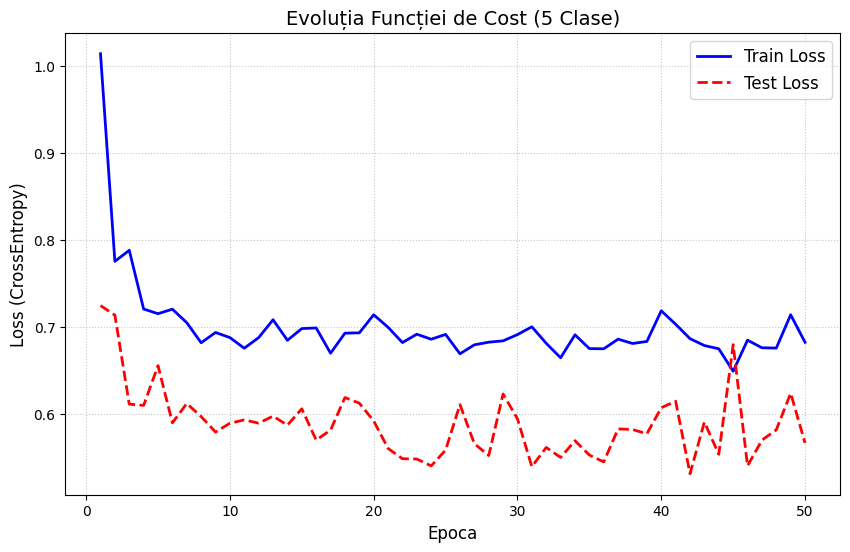

In [20]:
# ==========================================
# 7. Generarea și Salvarea Graficului
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), istoric_train_loss, label='Train Loss', color='blue', linewidth=2)
plt.plot(range(1, num_epochs + 1), istoric_test_loss, label='Test Loss', color='red', linestyle='--', linewidth=2)

plt.title('Evoluția Funcției de Cost (5 Clase)', fontsize=14)
plt.xlabel('Epoca', fontsize=12)
plt.ylabel('Loss (CrossEntropy)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.savefig('grafic_loss_resnet50_5clase.png', dpi=300, bbox_inches='tight')
print("\nAntrenament finalizat! Graficul a fost salvat.")
print(f"Cel mai bun model a fost salvat în: {cale_model_salvat}")
plt.show()